# 第9章 计算机视觉深度学习进阶

**本章包括以下内容**
- 计算机视觉的不同分支，包括图像分类、图像分割和目标检测
- 现代卷积神经网络的架构模式，包括残差连接、批量规范化和深度可分离卷积
- 对卷积神经网络所学内容进行可视化和解释的方法

## 9.1 三项基本的计算机视觉任务

- **图像分类**（image classification）：为图像指定一个或多个标签。
- **图像分割**（image segmentation）：将图像按不同的区域划分，如：视频会议的背景
- **目标检测**（object detection）：在目标周围绘制矩形，如：自动驾驶识别周围环境

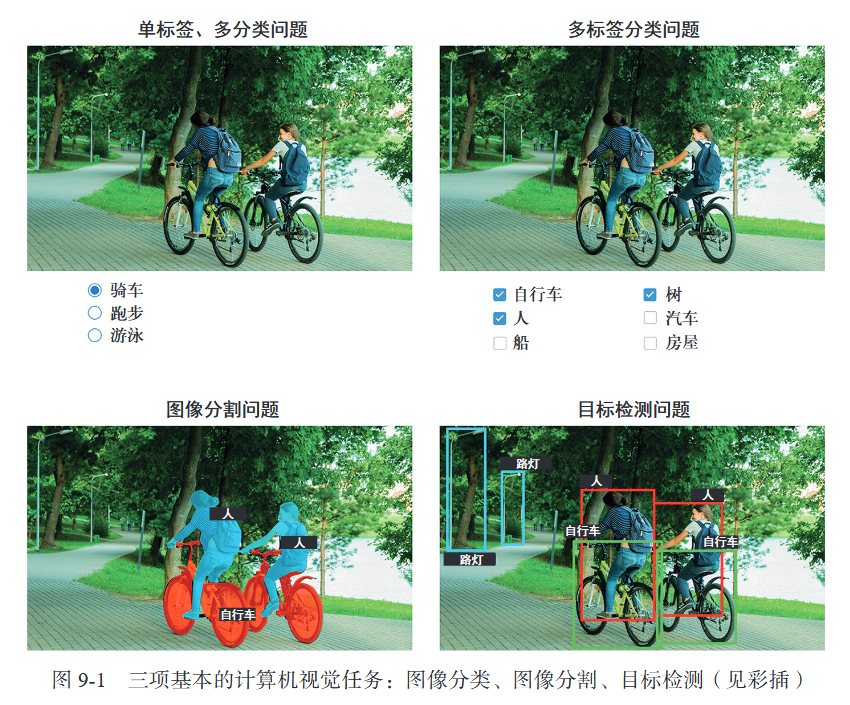

## 9.2 图像分割示例

两种图像分割：
- **语义分割**（semantic segmentation）
- **实例分割**（instance segmentation）

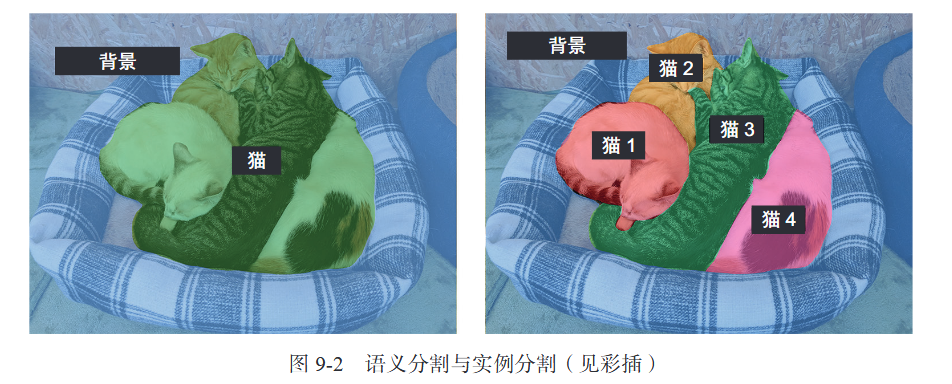

我们将使用 Oxford-IIIT 宠物数据集,其中包含 7390 张不同品种的猫狗图片,以及每张图片的前景 − 背景分割掩码。分割掩码(segmentation mask)相当于图像分割任务的标签:它是与输入图像大小相同的图像,具有单一颜色通道,其中每个整数值对应输入图像中相应像素的类别。本例中,分割掩码的像素值可以取以下三者之一。
- 1，表示前景
- 2，表示背景
- 3，表示轮廓

In [1]:
!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz 
!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz 
!tar -xf images.tar.gz 
!tar -xf annotations.tar.gz

--2025-02-18 12:57:42--  http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz [following]
--2025-02-18 12:57:43--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2025-02-18 12:57:44--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [app

准备输入文件路径的列表，和对应的掩码文件路径的列表。

In [ ]:
import os

input_dir = "images/"
target_dir = "annotations/trimaps"

input_img_paths = sorted(
    [os.path.join(input_dir, fname)
     for fname in os.listdir(input_dir)
     if fname.endswith(".jpg")]
)
target_paths = sorted(
    [os.path.join(target_dir, fname)
     for fname in os.listdir(target_dir)
     if fname.endswith(".png") and not fname.startswith(".")]
)

## 9.3 现代卷积神经网络架构模式

接下来将介绍一些基本的卷积神经网络架构最佳实践，特别是**残差连接**（residual connection）、**批量规范化**（batch normalization）、**可分离卷积**（separable convolution）。

### 9.3.1 模块化、层次结构和复用

将一个复杂系统变简单的通用方法是，将无定形的复杂内容构建为**模块**（module），将模块组织成**层次结构**（hierarchy），并对此**复用**（reuse）相同的模块，这种方法也被称为 MHR 方法。

**消融研究**（ablation study）是指系统性地移除一个系统的某些部分，使其变得更简单，以找到系统性能的真是来源。

### 9.3.2 残差连接

### 9.3.3 批量规范化

### 9.3.4 深度可分离卷积

**深度可分离卷积**（depthwise separable convolution）可以代替 `ConV2D` 层，并且可以让模型更加轻量、更加精简，还可以将模型性能提高几个百分点。

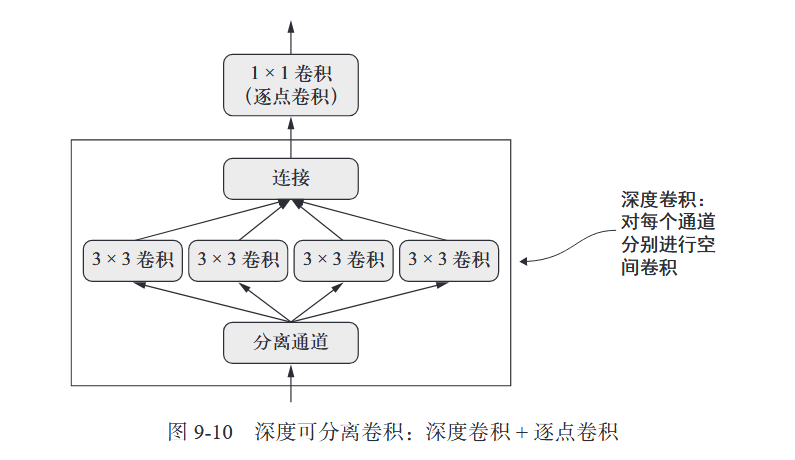

## 9.4 解释卷积神经网络学到的内容

### 9.4.1 中间激活值的可视化

**激活值**指某一层的输出。

In [ ]:
# 首先加载 8.2 节保存的模型
from tensorflow import keras
model = keras.models.load_model(
    "convnet_from_scratch_with_augmentation.keras"
)
model.summary()

OSError: SavedModel file does not exist at: convnet_from_scratch_with_augmentation.keras/{saved_model.pbtxt|saved_model.pb}

代码清单 9-6 预处理单张图像

In [4]:
from tensorflow import keras
import numpy as np

img_path = keras.utils.get_file(
    fname="cat.jpg",
    origin="https://img-datasets.s3.amazonaws.com/cat.jpg")

def get_img_array(img_path, target_size):
    img = keras.utils.load_img(
        img_path, target_size=target_size)
    array = keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return array

img_tensor = get_img_array(img_path, target_size=(180, 180))

81920/80329 [==============================] - 1s 7us/step


AttributeError: module 'tensorflow.keras.utils' has no attribute 'load_img'